# Applied Exercise 6 - Wage Data: Polynomial Regression and Step Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from ISLP import load_data
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings("ignore")

In [2]:
Wage = load_data("Wage")
X = Wage[["age"]]
y = Wage["wage"]

print("=" * 60)
print("WAGE DATA")
print("=" * 60)
print("Observations:", len(Wage))

WAGE DATA
Observations: 3000



POLYNOMIAL REGRESSION
 Degree      CV_MSE
      1 1677.205121
      2 1601.356479
      3 1596.246418
      4 1595.074236
      5 1595.071099
      6 1594.868498
      7 1593.864488
      8 1593.448852
      9 1596.119186
     10 1603.719084

Best polynomial degree = 8


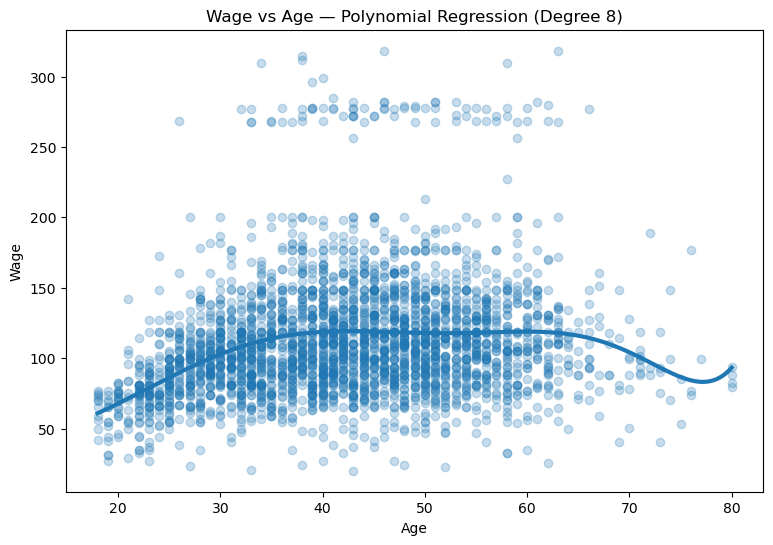

In [3]:
print("\n" + "=" * 60)
print("POLYNOMIAL REGRESSION")
print("=" * 60)

kf = KFold(n_splits=10, shuffle=True, random_state=1)
poly_results = []
for degree in range(1, 11):
    model = Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    poly_results.append([degree, mse])

poly_results = pd.DataFrame(poly_results, columns=["Degree", "CV_MSE"])
best_degree = int(poly_results.loc[poly_results["CV_MSE"].idxmin(), "Degree"])

print(poly_results.to_string(index=False))
print(f"\nBest polynomial degree = {best_degree}")

poly_model = Pipeline([("poly", PolynomialFeatures(degree=best_degree, include_bias=False)), ("lr", LinearRegression())])
poly_model.fit(X, y)

age_grid = np.linspace(X["age"].min(), X["age"].max(), 500).reshape(-1, 1)
wage_pred = poly_model.predict(age_grid)

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid, wage_pred, linewidth=3)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Polynomial Regression (Degree {best_degree})")
plt.show()

In [4]:
print("\n" + "=" * 60)
print("ANOVA COMPARISON")
print("=" * 60)

anova_models = []
for degree in range(1, 6):
    X_poly = np.column_stack([X["age"] ** i for i in range(1, degree + 1)])
    X_poly = sm.add_constant(X_poly)
    anova_models.append(sm.OLS(y, X_poly).fit())

anova_table = anova_lm(*anova_models)
print(anova_table)


ANOVA COMPARISON
   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


- Polynomial regression models of degrees 1 through 10 and used 10-fold cross-validation to select the degree. Cross-validation selected a polynomial of degree 8, which had the lowest CV MSE of 1593.45. However, the improvement after degree 3 was very small. The CV MSE decreased from 1596.25 for degree 3 to 1593.45 for degree 8.
- The ANOVA results provide a somewhat different conclusion. The quadratic and cubic terms were statistically significant, with p-values of approximately 2.36 × 10^-32 and 0.00168, respectively. The fourth-degree term had a p-value of approximately 0.051 (borderline at 95% CI), while the fifth-degree term was not significant (p ≈ 0.370).
- Thus, ANOVA suggests that a cubic model may be sufficient, whereas cross-validation selected degree 8. This difference occurs because ANOVA tests statistical significance of additional terms, whereas cross-validation evaluates predictive performance.


STEP FUNCTION
 Number_of_Cuts      CV_MSE
              2 1732.217912
              3 1683.428414
              4 1636.091836
              5 1631.093416
              6 1623.889511
              7 1612.766774
              8 1602.143809
              9 1610.918506
             10 1606.639281

Best number of cuts = 8


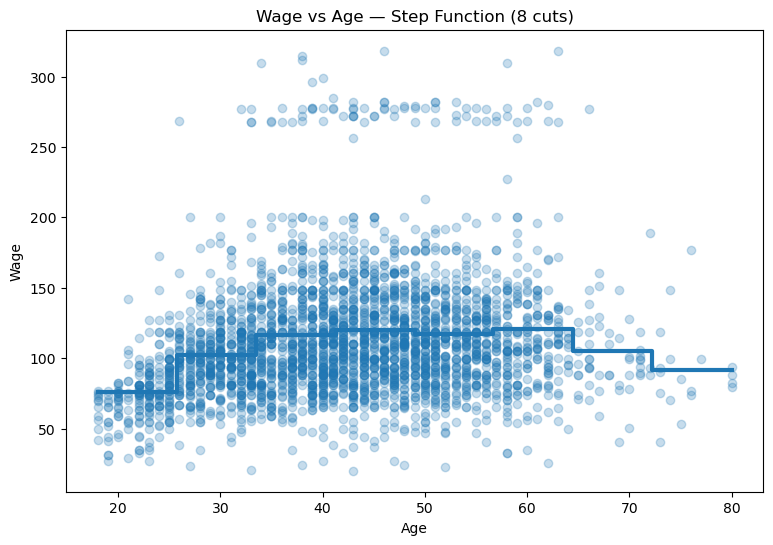

In [5]:
class StepFunction(BaseEstimator, TransformerMixin):
    def __init__(self, n_cuts=5):
        self.n_cuts = n_cuts

    def fit(self, X, y=None):
        x = np.asarray(X).ravel()
        self.bins_ = np.linspace(x.min(), x.max(), self.n_cuts + 1)
        return self

    def transform(self, X):
        x = np.asarray(X).ravel()
        groups = np.digitize(x, self.bins_[1:-1])
        return np.eye(self.n_cuts)[groups]

print("\n" + "=" * 60)
print("STEP FUNCTION")
print("=" * 60)

step_results = []
for cuts in range(2, 11):
    model = Pipeline([("step", StepFunction(n_cuts=cuts)), ("lr", LinearRegression())])
    mse = -cross_val_score(model, X, y, cv=kf, scoring="neg_mean_squared_error").mean()
    step_results.append([cuts, mse])

step_results = pd.DataFrame(step_results, columns=["Number_of_Cuts", "CV_MSE"])
best_cuts = int(step_results.loc[step_results["CV_MSE"].idxmin(), "Number_of_Cuts"])

print(step_results.to_string(index=False))
print(f"\nBest number of cuts = {best_cuts}")

step_model = Pipeline([("step", StepFunction(n_cuts=best_cuts)), ("lr", LinearRegression())])
step_model.fit(X, y)

age_grid_flat = np.linspace(X["age"].min(), X["age"].max(), 500)
step_pred = step_model.predict(age_grid_flat.reshape(-1, 1))

plt.figure(figsize=(9, 6))
plt.scatter(Wage["age"], Wage["wage"], alpha=0.25)
plt.plot(age_grid_flat, step_pred, linewidth=3, drawstyle="steps-mid")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title(f"Wage vs Age — Step Function ({best_cuts} cuts)")
plt.show()

- Step-function models using between 2 and 10 cuts and used 10-fold cross-validation to select the optimal number of cuts which is 8. Cross-validation selected a step function with 8 cuts, which produced the lowest CV MSE of approximately 1602.14.
- The CV error decreased as the number of cuts increased from 2 to 8, but increased again when using 9 or 10 cuts. This suggests that using too few cuts does not capture enough of the relationship between age and wage, while additional cuts beyond 8 provide little benefit and may begin to overfit the data.
- The step-function model had a slightly higher CV MSE than the best polynomial model, suggesting that the polynomial regression provides somewhat better predictive performance for wage based on age.

# Applied Exercise 7 - Exploring Other Predictors in the Wage Data

WAGE DATA — SELECTED PREDICTORS
         wage        education            maritl        jobclass  \
0   75.043154     1. < HS Grad  1. Never Married   1. Industrial   
1   70.476020  4. College Grad  1. Never Married  2. Information   
2  130.982177  3. Some College        2. Married   1. Industrial   
3  154.685293  4. College Grad        2. Married  2. Information   
4   75.043154       2. HS Grad       4. Divorced  2. Information   

           health health_ins  
0       1. <=Good      2. No  
1  2. >=Very Good      2. No  
2       1. <=Good     1. Yes  
3  2. >=Very Good     1. Yes  
4       1. <=Good     1. Yes  


<Figure size 900x500 with 0 Axes>

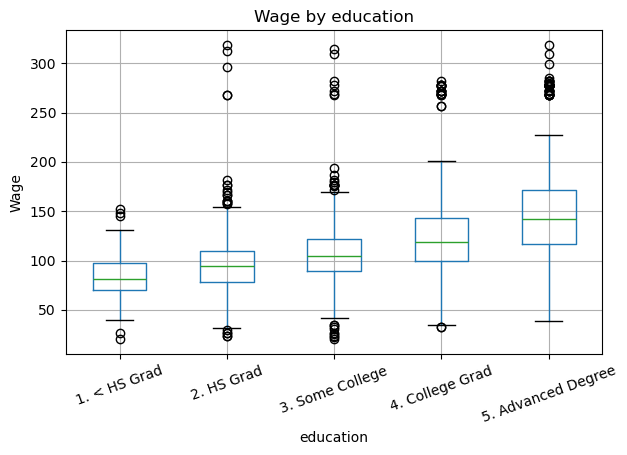

<Figure size 900x500 with 0 Axes>

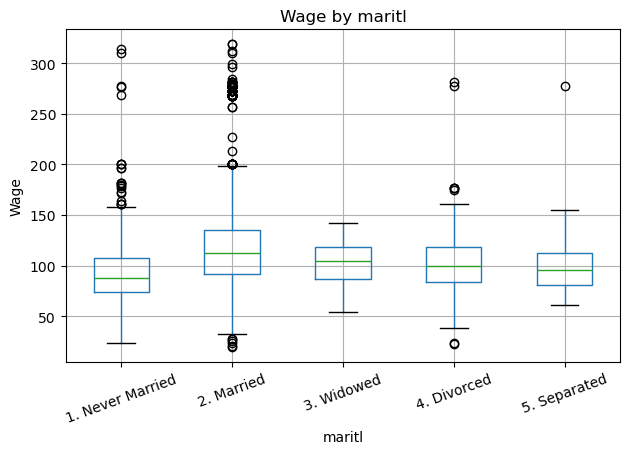

<Figure size 900x500 with 0 Axes>

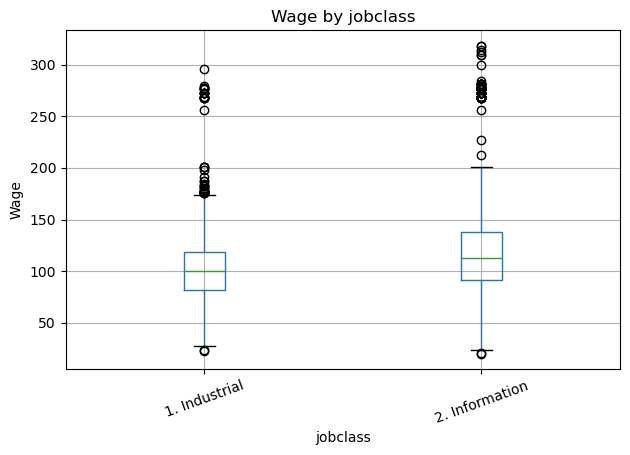

<Figure size 900x500 with 0 Axes>

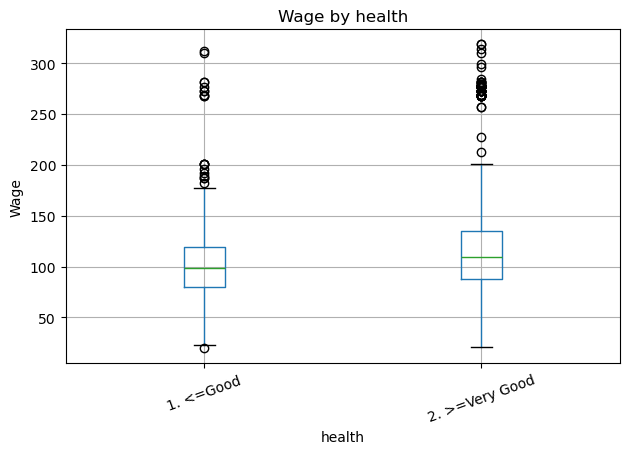

<Figure size 900x500 with 0 Axes>

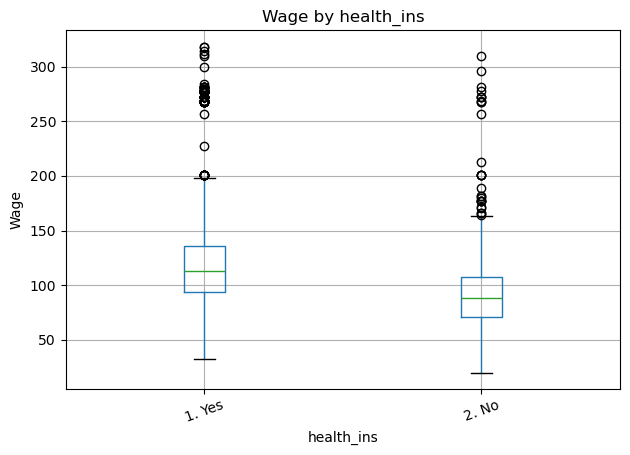

In [6]:
Wage = load_data("Wage")

print("=" * 60)
print("WAGE DATA — SELECTED PREDICTORS")
print("=" * 60)
print(Wage[['wage', 'education', 'maritl', 'jobclass', 'health', 'health_ins']].head())

categorical_vars = ['education', 'maritl', 'jobclass', 'health', 'health_ins']
for var in categorical_vars:
    plt.figure(figsize=(9, 5))
    Wage.boxplot(column='wage', by=var)
    plt.title(f'Wage by {var}')
    plt.suptitle('')
    plt.xlabel(var)
    plt.ylabel('Wage')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

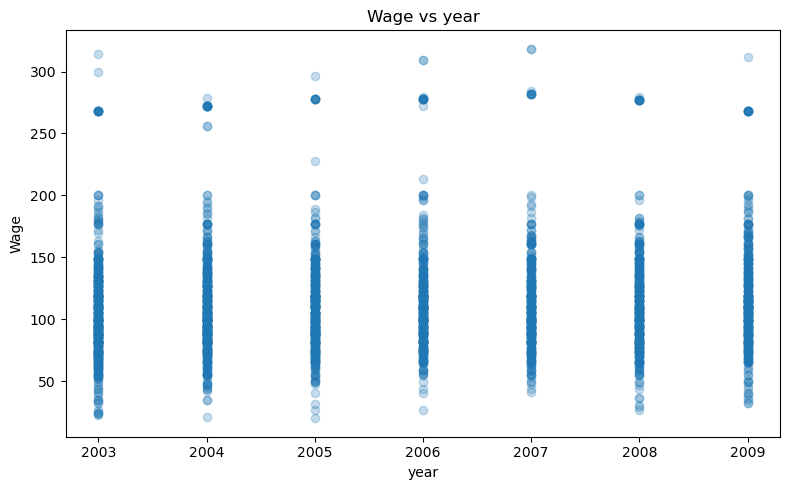

In [7]:
continuous_vars = ['year']
for var in continuous_vars:
    plt.figure(figsize=(8, 5))
    plt.scatter(Wage[var], Wage['wage'], alpha=0.25)
    plt.xlabel(var)
    plt.ylabel('Wage')
    plt.title(f'Wage vs {var}')
    plt.tight_layout()
    plt.show()

POLYNOMIAL REGRESSION — AGE
   Degree  Adjusted_R2           AIC
0       1     0.037953  30786.674044
1       2     0.081473  30648.798920
2       3     0.084186  30640.921874
3       4     0.085044  30639.107877
4       5     0.084985  30640.301396


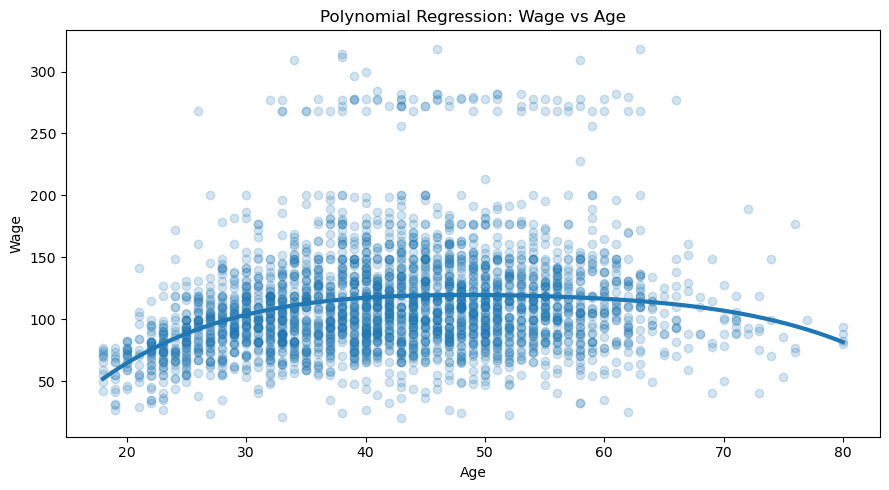

In [8]:
print("=" * 60)
print("POLYNOMIAL REGRESSION — AGE")
print("=" * 60)

degrees = [1, 2, 3, 4, 5]
poly_results = []

for d in degrees:
    X = np.column_stack([Wage['age'] ** i for i in range(1, d + 1)])
    X = sm.add_constant(X)
    model = sm.OLS(Wage['wage'], X).fit()
    poly_results.append([d, model.rsquared_adj, model.aic])

poly_results = pd.DataFrame(poly_results, columns=['Degree', 'Adjusted_R2', 'AIC'])
print(poly_results)

X_age = np.column_stack([Wage['age'] ** i for i in range(1, 5)])
X_age = sm.add_constant(X_age)
age_model = sm.OLS(Wage['wage'], X_age).fit()

age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 300)
X_grid = np.column_stack([age_grid ** i for i in range(1, 5)])
X_grid = sm.add_constant(X_grid)
age_pred = age_model.predict(X_grid)

plt.figure(figsize=(9, 5))
plt.scatter(Wage['age'], Wage['wage'], alpha=0.2)
plt.plot(age_grid, age_pred, linewidth=3)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Polynomial Regression: Wage vs Age')
plt.tight_layout()
plt.show()

SPLINE REGRESSION — AGE


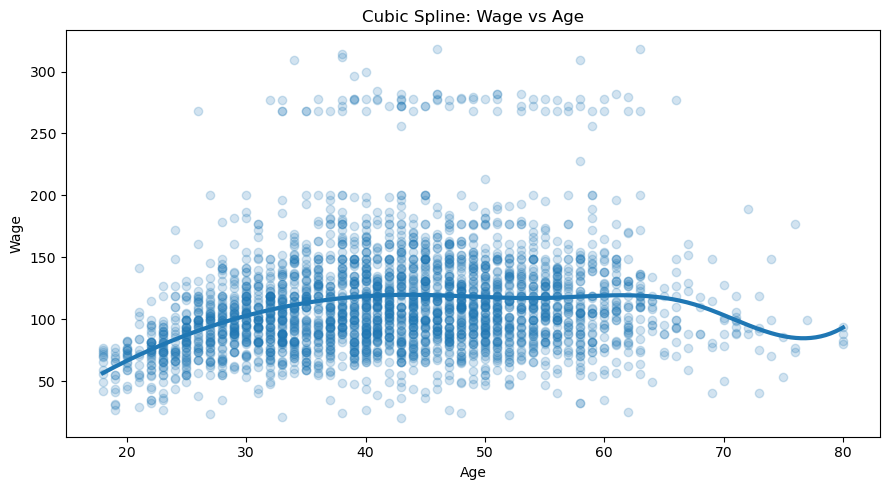

In [9]:
print("=" * 60)
print("SPLINE REGRESSION — AGE")
print("=" * 60)

X = Wage[['age']]
y = Wage['wage']

spline_model = make_pipeline(SplineTransformer(n_knots=6, degree=3), LinearRegression())
spline_model.fit(X, y)

age_pred_spline = spline_model.predict(pd.DataFrame({'age': age_grid}))

plt.figure(figsize=(9, 5))
plt.scatter(Wage['age'], Wage['wage'], alpha=0.2)
plt.plot(age_grid, age_pred_spline, linewidth=3)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Cubic Spline: Wage vs Age')
plt.tight_layout()
plt.show()

WAGE BY JOB CLASS
                      mean      median        std  count
jobclass                                                
1. Industrial   103.321129   99.689464  35.110674   1544
2. Information  120.592721  112.648896  46.131439   1456


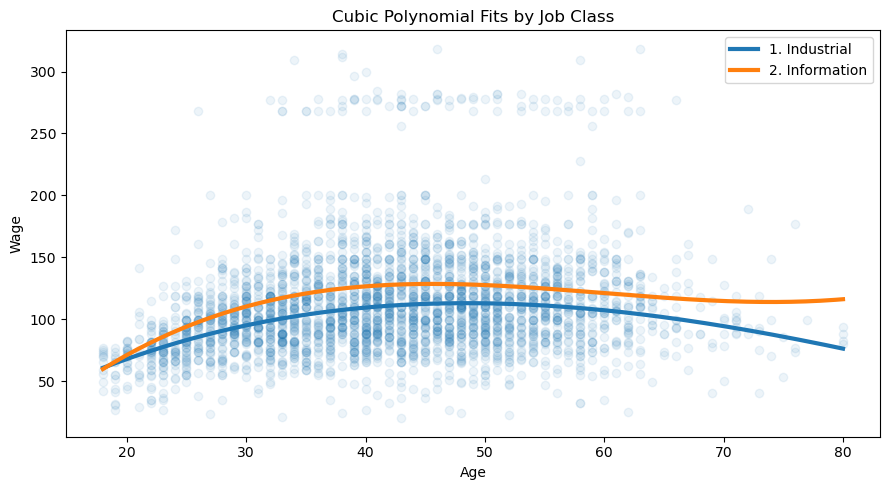

In [10]:
print("=" * 60)
print("WAGE BY JOB CLASS")
print("=" * 60)

print(Wage.groupby('jobclass')['wage'].agg(['mean', 'median', 'std', 'count']))
plt.figure(figsize=(9, 5))

for group in Wage['jobclass'].unique():
    subset = Wage[Wage['jobclass'] == group]
    X = np.column_stack([subset['age'] ** i for i in range(1, 4)])
    X = sm.add_constant(X)
    model = sm.OLS(subset['wage'], X).fit()

    grid = np.linspace(subset['age'].min(), subset['age'].max(), 200)
    X_grid = np.column_stack([grid ** i for i in range(1, 4)])
    X_grid = sm.add_constant(X_grid)

    plt.plot(grid, model.predict(X_grid), linewidth=3, label=group)

plt.scatter(Wage['age'], Wage['wage'], alpha=0.08)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Cubic Polynomial Fits by Job Class')
plt.legend()
plt.tight_layout()
plt.show()

- The exploratory analysis shows that wage is associated with several predictors besides age.
- Education, job class, health status and health insurance show visible differences in wage distributions across their categories.
- The relationship between age and wage is clearly non-linear, so a flexible polynomial or spline model provides a better representation than a simple linear relationship.
- Job class also appears to be associated with wage, and the relationship between age and wage can differ across job classes.
- Overall, the results suggest that wage is influenced by both categorical and continuous predictors, and flexible non-linear models can capture patterns that a simple linear model may miss.

# Applied Exercise 8 - Non-Linear Models on the Auto Data Set

In [11]:
Auto = load_data("Auto")
Auto = Auto.drop(columns=["Unnamed: 0"], errors="ignore")
predictors = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "year", "origin"]

In [12]:
results = []
for x in predictors:
    data = Auto[[x, "mpg"]].dropna()
    linear = ols(f"mpg ~ {x}", data=data).fit()
    quadratic = ols(f"mpg ~ {x} + I({x}**2)", data=data).fit()
    cubic = ols(f"mpg ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()
    results.append([x, linear.rsquared_adj, quadratic.rsquared_adj, cubic.rsquared_adj])

results = pd.DataFrame(results, columns=["Predictor", "Linear Adj R2", "Quadratic Adj R2", "Cubic Adj R2"])

print("=" * 60)
print("POLYNOMIAL REGRESSION RESULTS")
print("=" * 60)
print(results.to_string(index=False))

print("\n" + "=" * 60)
print("BEST POLYNOMIAL MODELS")
print("=" * 60)
for x in predictors:
    data = Auto[[x, "mpg"]].dropna()
    models = {d: ols("mpg ~ " + " + ".join([x] + [f"I({x}**{j})" for j in range(2, d + 1)]), data=data).fit() for d in [1, 2, 3]}
    best_d = max(models, key=lambda d: models[d].rsquared_adj)
    print(f"{x}: degree {best_d}, adjusted R² = {models[best_d].rsquared_adj:.4f}")

POLYNOMIAL REGRESSION RESULTS
   Predictor  Linear Adj R2  Quadratic Adj R2  Cubic Adj R2
   cylinders       0.603675          0.605434      0.638491
displacement       0.647327          0.687209      0.687246
  horsepower       0.604938          0.685953      0.685803
      weight       0.691842          0.713683      0.712947
acceleration       0.177102          0.189820      0.189288
        year       0.335328          0.364274      0.363833
      origin       0.317716          0.328413      0.328413

BEST POLYNOMIAL MODELS
cylinders: degree 3, adjusted R² = 0.6385
displacement: degree 3, adjusted R² = 0.6872
horsepower: degree 2, adjusted R² = 0.6860
weight: degree 2, adjusted R² = 0.7137
acceleration: degree 2, adjusted R² = 0.1898
year: degree 2, adjusted R² = 0.3643
origin: degree 2, adjusted R² = 0.3284


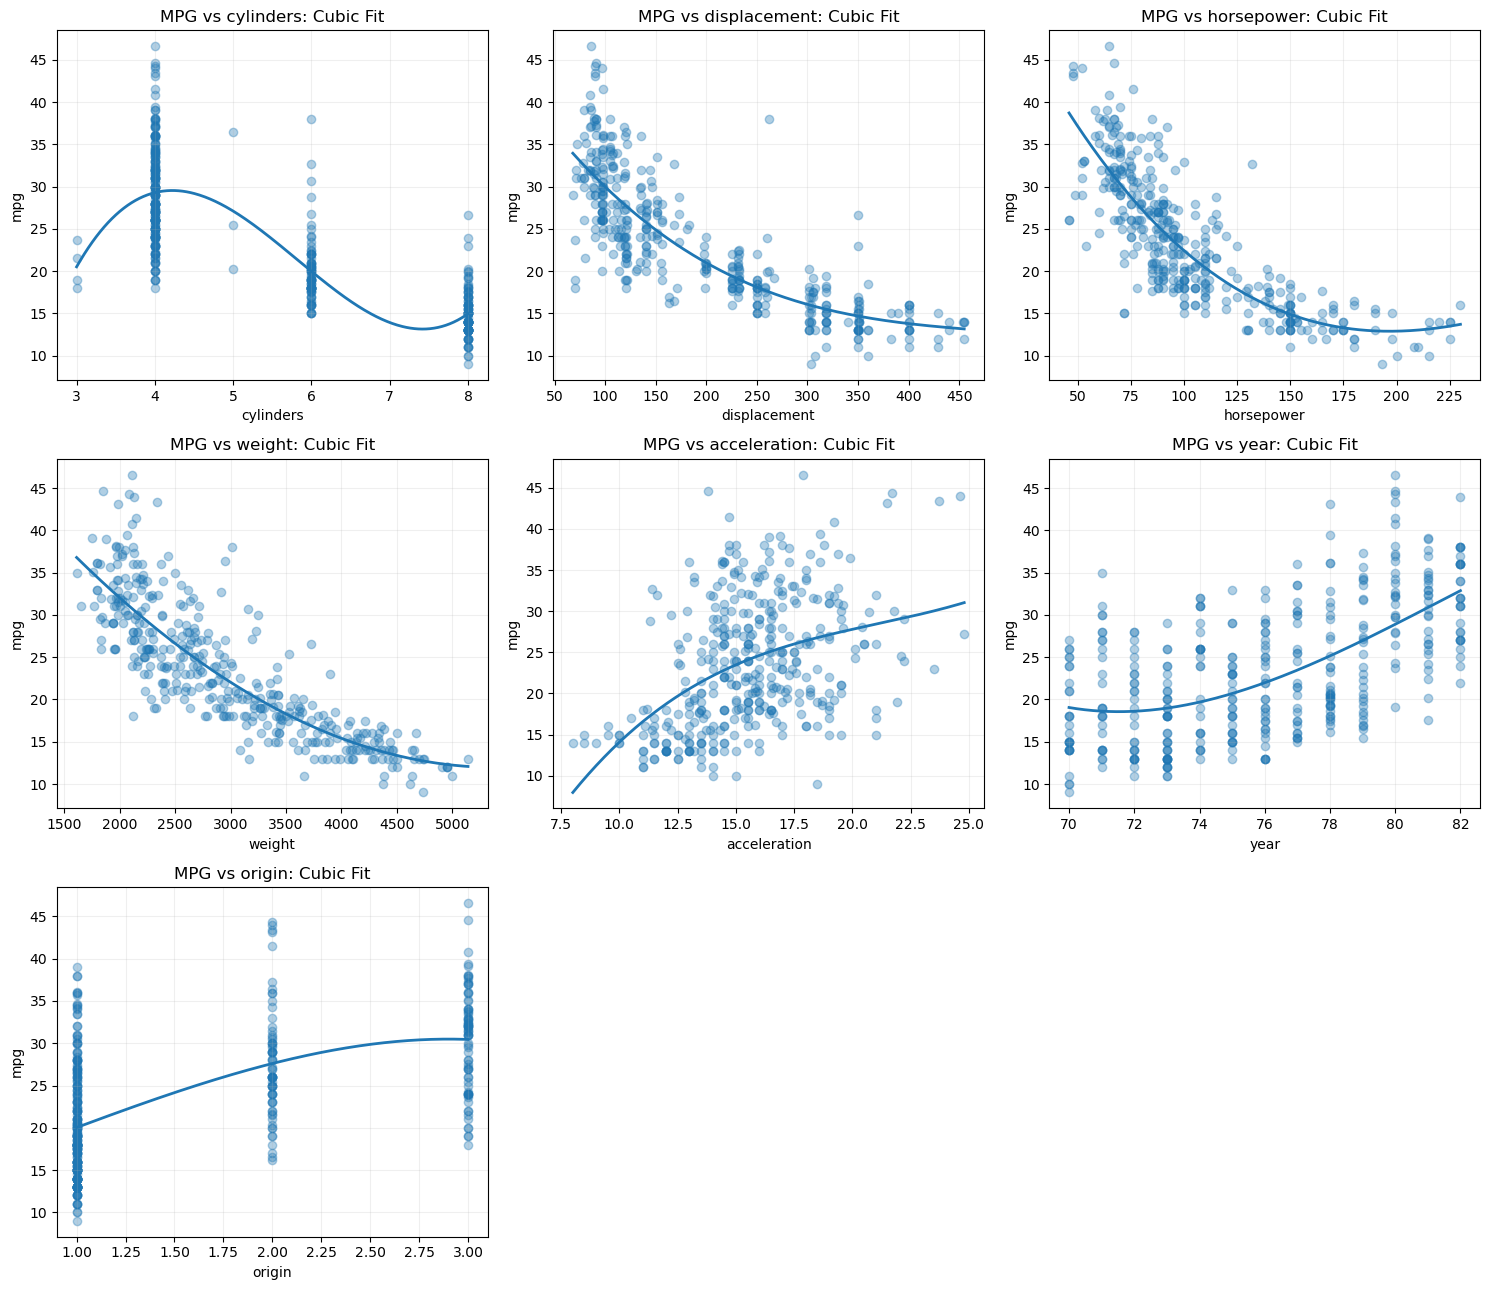

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.ravel()

for i, x in enumerate(predictors):
    data = Auto[[x, "mpg"]].dropna()
    model = ols(f"mpg ~ {x} + I({x}**2) + I({x}**3)", data=data).fit()
    grid = np.linspace(data[x].min(), data[x].max(), 300)
    pred = model.predict(pd.DataFrame({x: grid}))
    axes[i].scatter(data[x], data["mpg"], alpha=0.35)
    axes[i].plot(grid, pred, linewidth=2)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel("mpg")
    axes[i].set_title(f"MPG vs {x}: Cubic Fit")
    axes[i].grid(alpha=0.2)

for j in range(len(predictors), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

- The polynomial models show that several predictors have clear non-linear relationships with mpg. In particular, displacement, horsepower, weight,
and year show substantial departures from a simple linear relationship.
- The polynomial regression results and fitted curves indicate that adding quadratic and/or cubic terms can improve the fit for several predictors.
- The scatterplots also provide visual evidence of these departures from linearity.